Moran's I for spatially autocorrelated data: 0.9442
Moran's I for random noise data: -0.0200
SSI for spatially autocorrelated data: 23.0259
SSI for random noise data: -2.5027


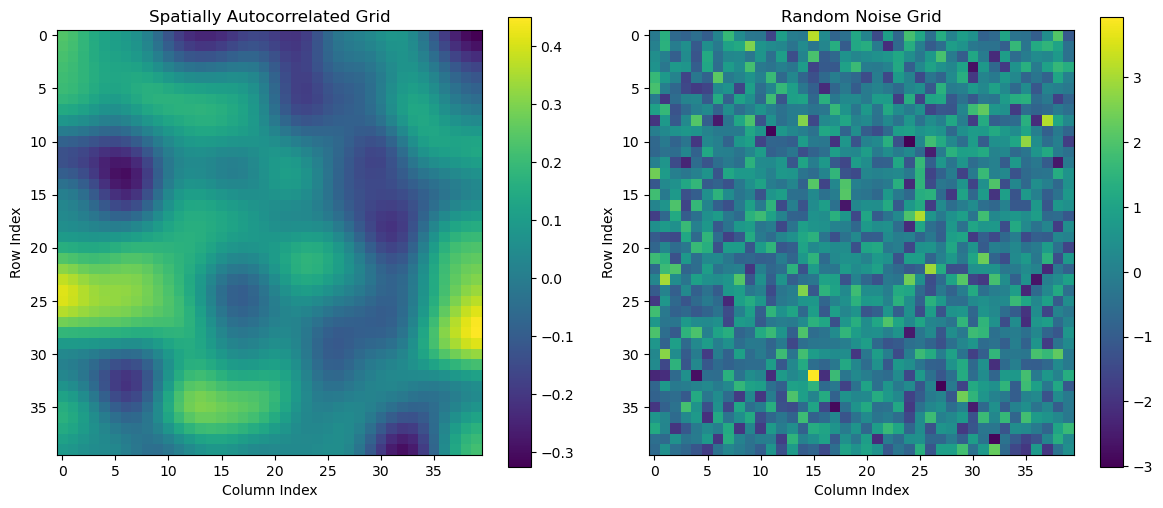

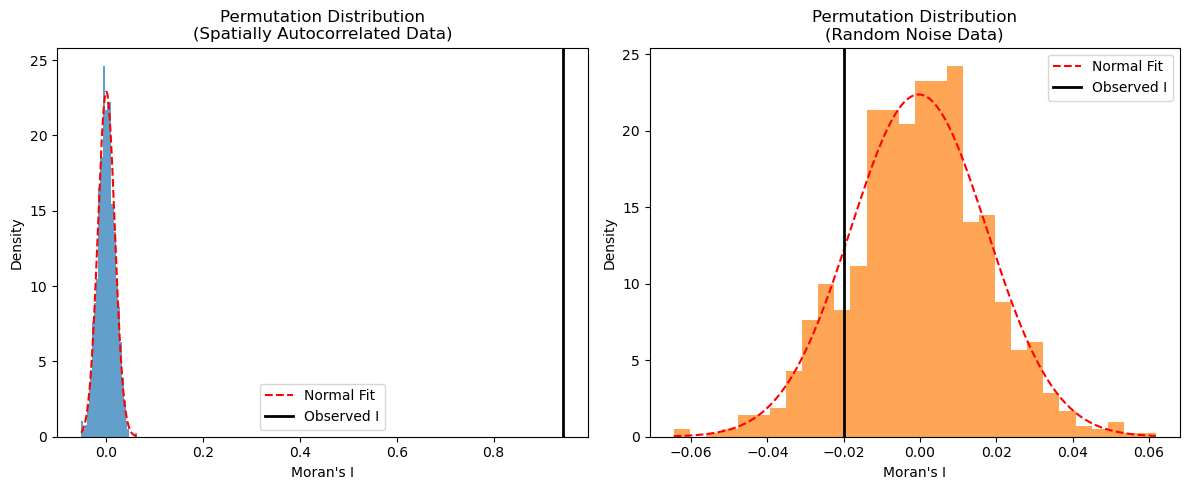

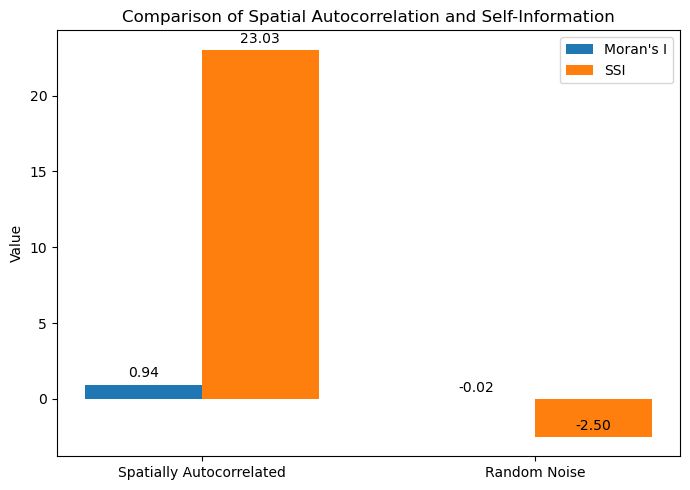

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from scipy.ndimage import gaussian_filter

# -------------------------------
# Compute Moran's I for a grid using a rook contiguity scheme.
# 
# Formula: I = (N/W) * ( Σ[i,j] w_ij (x_i - x̄)(x_j - x̄) / Σ_i (x_i - x̄)^2 )
# where N is the total number of grid cells, and W is the total weight (number of neighbor connections).
# -------------------------------
def morans_I(grid):
    rows, cols = grid.shape
    N = grid.size
    x = grid.flatten()
    mean_x = x.mean()
    denominator = np.sum((x - mean_x) ** 2)
    
    numerator = 0.0
    W = 0  # total sum of weights
    
    # Loop over each grid cell and sum the products for neighboring pairs.
    for i in range(rows):
        for j in range(cols):
            xi = grid[i, j]
            # Define neighbors using rook contiguity (up, down, left, right)
            neighbors = []
            if i > 0:
                neighbors.append(grid[i - 1, j])
            if i < rows - 1:
                neighbors.append(grid[i + 1, j])
            if j > 0:
                neighbors.append(grid[i, j - 1])
            if j < cols - 1:
                neighbors.append(grid[i, j + 1])
            # Accumulate the contribution of each neighbor
            for neighbor in neighbors:
                numerator += (xi - mean_x) * (neighbor - mean_x)
            W += len(neighbors)
    
    I = (N / W) * (numerator / denominator)
    return I

# -------------------------------
# Permutation test for estimating the null distribution of Moran's I.
# Randomly permute the grid values 'num_perm' times and compute I for each permutation.
# -------------------------------
def permutation_distribution(grid, num_perm=1000, seed=None):
    if seed is not None:
        np.random.seed(seed)
    N = grid.size
    permuted_Is = np.zeros(num_perm)
    flat_grid = grid.flatten()
    
    for i in range(num_perm):
        permuted = np.random.permutation(flat_grid)
        permuted_grid = permuted.reshape(grid.shape)
        permuted_Is[i] = morans_I(permuted_grid)
    return permuted_Is

# -------------------------------
# Compute spatial self-information (SSI) based on the estimated probability density.
#
# The SSI is defined as:
#    J = - log( p(I_obs) )
# where p(I_obs) is obtained from the probability density function (PDF)
# of the fitted normal distribution (using the permutation distribution).
# -------------------------------
def compute_ssi(I_obs, permuted_Is):
    mu = np.mean(permuted_Is)
    sigma = np.std(permuted_Is, ddof=1)
    epsilon = 1e-10  # to avoid division by zero
    sigma = sigma if sigma > epsilon else epsilon
    pdf_val = stats.norm.pdf(I_obs, loc=mu, scale=sigma)
    pdf_val = max(pdf_val, 1e-10)  # ensure density is positive
    J = -np.log(pdf_val)
    return J, mu, sigma

# -------------------------------
# Create synthetic spatial datasets.
#
# Two grids are generated:
# 1. A spatially autocorrelated grid via Gaussian filtering.
# 2. A grid with pure random noise.
# -------------------------------
def create_synthetic_data(grid_size=(40, 40), sigma_filter=2.5, seed=None):
    if seed is not None:
        np.random.seed(seed)
    # Generate a random noise grid and smooth it for spatial autocorrelation
    noise = np.random.randn(*grid_size)
    spatial_data = gaussian_filter(noise, sigma=sigma_filter)
    
    # Generate a grid that is purely random (without smoothing)
    random_data = np.random.randn(*grid_size)
    return spatial_data, random_data

# -------------------------------
# Main function to execute analysis and plotting.
# -------------------------------
def main():
    grid_size = (40, 40)
    num_perm = 1000
    seed = 42  # for reproducibility
    
    # Generate synthetic grids
    data_autocorr, data_random = create_synthetic_data(grid_size=grid_size, sigma_filter=2.5, seed=seed)
    
    # Compute Moran's I for both grids
    I_autocorr = morans_I(data_autocorr)
    I_random = morans_I(data_random)
    
    print("Moran's I for spatially autocorrelated data: {:.4f}".format(I_autocorr))
    print("Moran's I for random noise data: {:.4f}".format(I_random))
    
    # Estimate permutation distributions for both grids
    perm_Is_autocorr = permutation_distribution(data_autocorr, num_perm=num_perm, seed=seed)
    perm_Is_random = permutation_distribution(data_random, num_perm=num_perm, seed=seed+1)
    
    # Compute the Spatial Self-Information (SSI)
    J_autocorr, mu_auto, sigma_auto = compute_ssi(I_autocorr, perm_Is_autocorr)
    J_random, mu_rand, sigma_rand = compute_ssi(I_random, perm_Is_random)
    
    print("SSI for spatially autocorrelated data: {:.4f}".format(J_autocorr))
    print("SSI for random noise data: {:.4f}".format(J_random))
    
    # -------------------------------
    # Visualize the grids (Heatmaps)
    # -------------------------------
    fig_grids, axs_grids = plt.subplots(1, 2, figsize=(12, 5))
    
    # Plot spatially autocorrelated grid
    im0 = axs_grids[0].imshow(data_autocorr, cmap='viridis')
    axs_grids[0].set_title("Spatially Autocorrelated Grid")
    axs_grids[0].set_xlabel("Column Index")
    axs_grids[0].set_ylabel("Row Index")
    fig_grids.colorbar(im0, ax=axs_grids[0])
    
    # Plot random noise grid
    im1 = axs_grids[1].imshow(data_random, cmap='viridis')
    axs_grids[1].set_title("Random Noise Grid")
    axs_grids[1].set_xlabel("Column Index")
    axs_grids[1].set_ylabel("Row Index")
    fig_grids.colorbar(im1, ax=axs_grids[1])
    
    plt.tight_layout()
    plt.show()
    fig_grids.savefig("grid_example.pdf", format = 'pdf')
    
    # -------------------------------
    # Plot the permutation distributions with observed values.
    # -------------------------------
    fig_perm, axs_perm = plt.subplots(1, 2, figsize=(12, 5))
    
    # Plot permutation distribution for spatially autocorrelated data
    axs_perm[0].hist(perm_Is_autocorr, bins=30, density=True, alpha=0.7, color='C0')
    x_vals_auto = np.linspace(min(perm_Is_autocorr), max(perm_Is_autocorr), 200)
    pdf_auto = stats.norm.pdf(x_vals_auto, loc=mu_auto, scale=sigma_auto)
    axs_perm[0].plot(x_vals_auto, pdf_auto, 'r--', label='Normal Fit')
    axs_perm[0].axvline(I_autocorr, color='k', linestyle='-', linewidth=2, label="Observed I")
    axs_perm[0].set_title("Permutation Distribution\n(Spatially Autocorrelated Data)")
    axs_perm[0].set_xlabel("Moran's I")
    axs_perm[0].set_ylabel("Density")
    axs_perm[0].legend()
    
    # Plot permutation distribution for random noise data
    axs_perm[1].hist(perm_Is_random, bins=30, density=True, alpha=0.7, color='C1')
    x_vals_rand = np.linspace(min(perm_Is_random), max(perm_Is_random), 200)
    pdf_rand = stats.norm.pdf(x_vals_rand, loc=mu_rand, scale=sigma_rand)
    axs_perm[1].plot(x_vals_rand, pdf_rand, 'r--', label='Normal Fit')
    axs_perm[1].axvline(I_random, color='k', linestyle='-', linewidth=2, label="Observed I")
    axs_perm[1].set_title("Permutation Distribution\n(Random Noise Data)")
    axs_perm[1].set_xlabel("Moran's I")
    axs_perm[1].set_ylabel("Density")
    axs_perm[1].legend()
    
    plt.tight_layout()
    plt.show()
    fig_perm.savefig("dist_example.pdf", format = 'pdf')
    
    # -------------------------------
    # Bar plot comparing Moran's I and SSI for the two datasets.
    # -------------------------------
    fig_bar, ax_bar = plt.subplots(figsize=(7, 5))
    labels = ['Spatially Autocorrelated', 'Random Noise']
    morans_I_vals = [I_autocorr, I_random]
    ssi_vals = [J_autocorr, J_random]
    
    x = np.arange(len(labels))
    width = 0.35  # width of each bar
    
    rects1 = ax_bar.bar(x - width/2, morans_I_vals, width, label="Moran's I")
    rects2 = ax_bar.bar(x + width/2, ssi_vals, width, label="SSI")
    
    ax_bar.set_ylabel("Value")
    ax_bar.set_title("Comparison of Spatial Autocorrelation and Self-Information")
    ax_bar.set_xticks(x)
    ax_bar.set_xticklabels(labels)
    ax_bar.legend()
    
    def autolabel(rects):
        for rect in rects:
            height = rect.get_height()
            ax_bar.annotate(f'{height:.2f}',
                            xy=(rect.get_x() + rect.get_width()/2, height),
                            xytext=(0, 3),  # vertical offset
                            textcoords="offset points",
                            ha='center', va='bottom')
    
    autolabel(rects1)
    autolabel(rects2)
    
    plt.tight_layout()
    plt.show()

if __name__ == '__main__':
    main()


Gradient Grid Moran's I = 0.9744
SSI (Std Null): 23.0259
SSI (Trend-Preserving): -10.3286


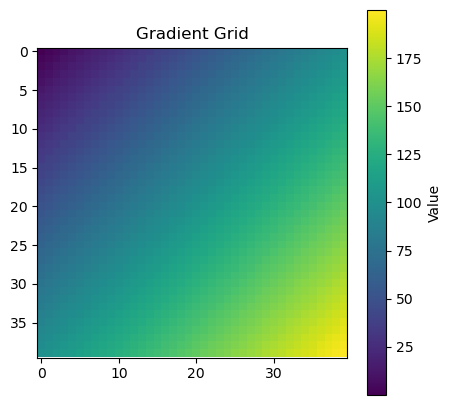

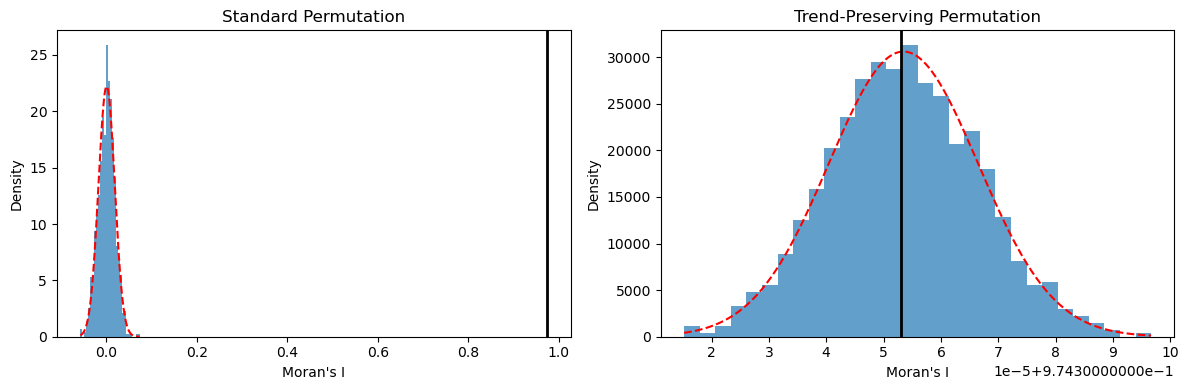

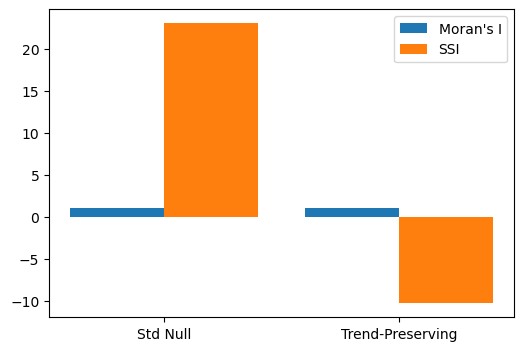

In [21]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# -------------------------------
# Moran's I (rook contiguity)
def morans_I(grid):
    rows, cols = grid.shape
    N = grid.size
    x = grid.flatten()
    mean_x = x.mean()
    denom = np.sum((x - mean_x)**2)
    num = 0.0
    W = 0
    for i in range(rows):
        for j in range(cols):
            xi = grid[i,j]
            neigh = []
            if i>0:       neigh.append(grid[i-1,j])
            if i<rows-1:  neigh.append(grid[i+1,j])
            if j>0:       neigh.append(grid[i,j-1])
            if j<cols-1:  neigh.append(grid[i,j+1])
            for v in neigh:
                num += (xi-mean_x)*(v-mean_x)
            W += len(neigh)
    return (N/W)*(num/denom)

# -------------------------------
# Standard permutation null
def perm_std(grid, B=1000, seed=None):
    if seed is not None: np.random.seed(seed)
    flat = grid.flatten()
    out = np.zeros(B)
    for b in range(B):
        p = np.random.permutation(flat).reshape(grid.shape)
        out[b] = morans_I(p)
    return out

# -------------------------------
# Trend‑preserving permutation null
def perm_trend(grid, B=1000, seed=None):
    if seed is not None: np.random.seed(seed)
    rows, cols = grid.shape
    Xc, Yc = np.meshgrid(np.arange(cols), np.arange(rows))
    M = rows*cols
    A = np.vstack([np.ones(M), Xc.flatten(), Yc.flatten()]).T
    vals = grid.flatten()
    beta, *_ = np.linalg.lstsq(A, vals, rcond=None)
    trend = A.dot(beta)
    resid = vals - trend
    
    out = np.zeros(B)
    for b in range(B):
        pr = np.random.permutation(resid)
        g = (trend + pr).reshape(grid.shape)
        out[b] = morans_I(g)
    return out

# -------------------------------
# Compute SSI = -ln(pdf) under normal fit
def compute_ssi(I_obs, null_vals):
    mu, sigma = null_vals.mean(), null_vals.std(ddof=1)
    sigma = max(sigma, 1e-10)
    pdf = stats.norm.pdf(I_obs, loc=mu, scale=sigma)
    pdf = max(pdf, 1e-10)
    return -np.log(pdf), mu, sigma

# -------------------------------
# Create strong gradient grid only
def make_gradient(grid_size=(40,40), seed=None):
    if seed is not None: np.random.seed(seed)
    x = np.linspace(0,1,grid_size[1])
    y = np.linspace(0,1,grid_size[0])
    X, Y = np.meshgrid(x,y)
    return 100*(X+Y) + 0.1*np.random.randn(*grid_size)

# -------------------------------
# Main
def main():
    grid = make_gradient(seed=42)
    I_obs = morans_I(grid)
    print(f"Gradient Grid Moran's I = {I_obs:.4f}")
    
    # two nulls
    null1 = perm_std(grid, B=1000, seed=1)
    null2 = perm_trend(grid, B=1000, seed=1)
    
    J1, mu1, s1 = compute_ssi(I_obs, null1)
    J2, mu2, s2 = compute_ssi(I_obs, null2)
    print(f"SSI (Std Null): {J1:.4f}")
    print(f"SSI (Trend-Preserving): {J2:.4f}")
    
    # visualize gradient grid
    plt.figure(figsize=(5,5))
    plt.imshow(grid, cmap='viridis')
    plt.title("Gradient Grid")
    plt.colorbar(label='Value')
    plt.show()
    
    # visualize null distributions
    fig, axs = plt.subplots(1,2,figsize=(12,4))
    for ax, null, mu, s, title in zip(
        axs,
        [null1, null2],
        [mu1, mu2],
        [s1, s2],
        ["Standard Permutation","Trend-Preserving Permutation"]
    ):
        ax.hist(null, bins=30, density=True, alpha=0.7, color='C0')
        xs = np.linspace(null.min(), null.max(), 200)
        ax.plot(xs, stats.norm.pdf(xs, mu, s), 'r--')
        ax.axvline(I_obs, color='k', lw=2)
        ax.set_title(title)
        ax.set_xlabel("Moran's I")
        ax.set_ylabel("Density")
    plt.tight_layout()
    plt.show()
    
    # bar plot
    labels = ["Std Null","Trend-Preserving"]
    Ivals = [I_obs, I_obs]
    Jvals = [J1, J2]
    x = np.arange(2)
    fig, ax = plt.subplots(figsize=(6,4))
    ax.bar(x-0.2, Ivals, 0.4, label="Moran's I")
    ax.bar(x+0.2, Jvals, 0.4, label="SSI")
    ax.set_xticks(x); ax.set_xticklabels(labels)
    ax.legend()
    plt.show()

if __name__=='__main__':
    main()
